## Importación de librerías

In [1]:
import random
from collections import Counter

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Julio
[nltk_data]     GR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Julio
[nltk_data]     GR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Julio
[nltk_data]     GR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Precargado de datos

In [2]:
def identificar_clusters(text, labels, ye, encod):
    cluster_labels = {}
    for cluster in range(text['clf'].n_clusters):
        cluster_indices = np.where(labels == cluster)[0]
        if len(cluster_indices) == 0:
            cluster_labels[cluster] = "Sin datos"
        else:
            cluster_true_labels = ye[cluster_indices]
            most_common_label_num = Counter(cluster_true_labels).most_common(1)[0][0]
            most_common_label_str = encod.inverse_transform([[most_common_label_num]])[0][0]
            cluster_labels[cluster] = most_common_label_str

    return cluster_labels


dataset = 'news_reducido.csv'

# Leer los datos en formato csv
data = pd.read_csv(dataset)

# Nos quedamos con el texto (puedes quedarte con más información si quieres)
X = data['text'].astype(str).to_numpy()

# Ahora, procesamos las etiquetas, para cada clase, le asignamos un valor numérico entre 0 y el número de clases
enc = OrdinalEncoder()
y = enc.fit_transform(np.reshape(data['category'], (-1, 1))).reshape(-1)

# Hacemos la partición train-test con Validacion cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf.get_n_splits(X, y)

5

Aplicacion de pipeline y entrenamiento para clustering

In [4]:
# Pipeline optima para clustering #
text_tfidf = Pipeline([
    ('vect', CountVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', KMeans(init='k-means++', max_iter=300, n_clusters=4, random_state=200)),
])

accuracies = np.zeros(5)
text_tfidf.fit(X)
labels = text_tfidf.predict(X)
acc = np.mean(labels == y)
print(f'TF-IDF: {acc}')
etiquetas_usadas = identificar_clusters(text_tfidf, labels, y, enc)
print(etiquetas_usadas)

TF-IDF: 0.5282
{0: 'TRAVEL', 1: 'POLITICS', 2: 'ENTERTAINMENT', 3: 'WELLNESS'}


## Preparación de datos para TSNE

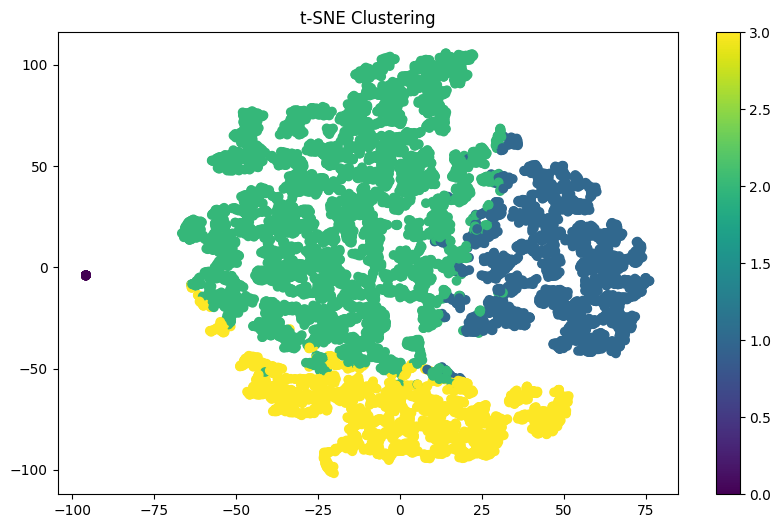

In [5]:
transformed = text_tfidf.transform(X)
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(transformed)
# Visualizacion de los clusteres
plt.figure(figsize=(10, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='viridis', marker='o')
plt.title('t-SNE Clustering')
plt.colorbar()
plt.show()